# 🧠 ROI Stack Explorer
Load an ROI stack, look at it, and prepare it for ML in a few lines.
Run the cells top to bottom. All helpers come from [`roi_utils.py`](https://github.com/24f2007780/colab_export_roi).

## 1. Setup

In [81]:
# !wget -q -O roi_utils.py https://raw.githubusercontent.com/24f2007780/colab_export_roi/refs/heads/main/roi_utils.py

import sys
from pathlib import Path
if ".." not in sys.path:
    sys.path.append("..")

# Data directory: notebooks/data or stroke_notebooks/data
DATA_DIR = Path("data") if Path("data").is_dir() else Path("../data") if Path("../data").is_dir() else Path(".")

import importlib, roi_utils
importlib.reload(roi_utils)                     # in case an older copy was already imported this session
from roi_utils import *

# Specimen and stain configuration
BIOSAMPLE_ID = 587
STAIN = "IHCS"


## 2. Load your ROI stack

Filename : ROI_SE1019_X12000_Y12000_Z117_768x768_L4_axial_IHCS.npy
Shape    : (117, 768, 768, 3)
Dtype    : uint8
Size     : 197.44 MB

Parsed Metadata:
  • Center X                 : 12000
  • Center Y                 : 12000
  • Z / section information  : Section 1019, Z=117
  • Stain                    : IHCS
  • Resolution               : Level 4


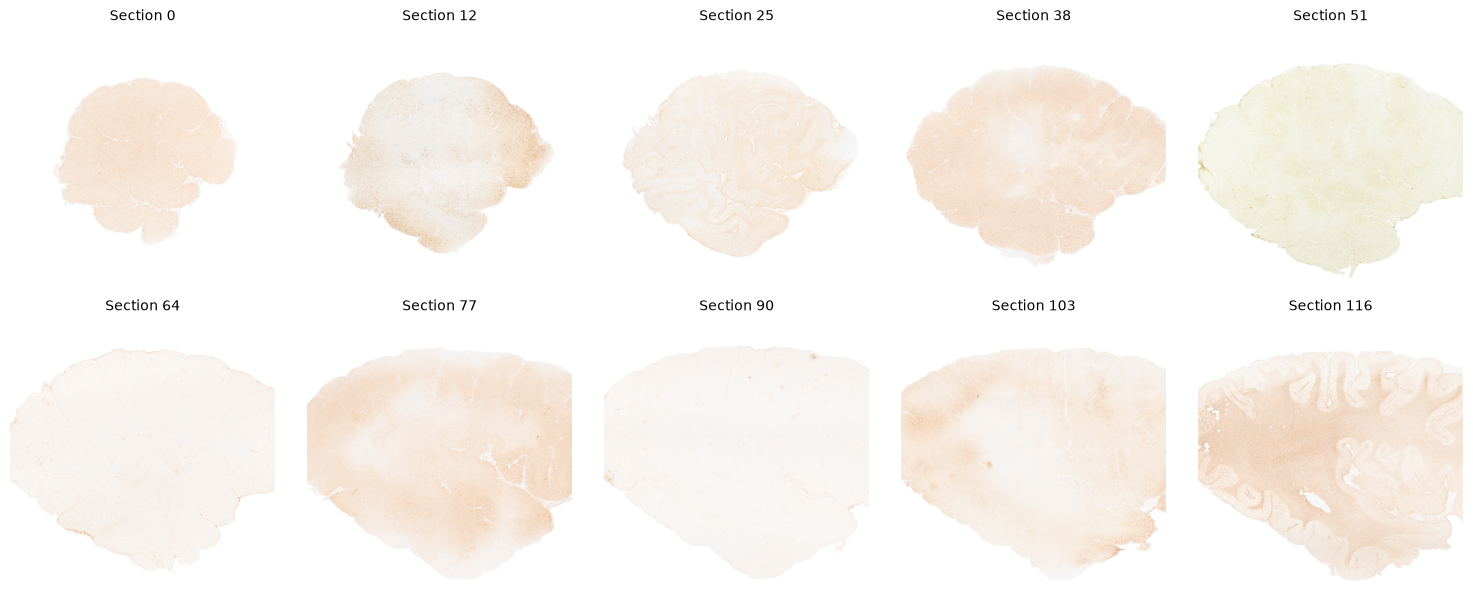

{'filename': 'ROI_SE1019_X12000_Y12000_Z117_768x768_L4_axial_IHCS.npy', 'center_section': 1019, 'stain': 'IHCS'}


In [80]:
# PASTE the Google Drive file ID of an ROI stack (e.g. centred on SE1019 for the configured stain):
ROI_DRIVE_ID="1L1_QprfzYrT8v_hhj8LXJJCRq9duIrbQ"
roi, meta = load_and_preview_roi(ROI_DRIVE_ID, return_meta=True)
print(meta)

# Already have a local .npy file? Use this instead:
# roi = load_roi("my_roi.npy")


## 3. Explore

In [82]:
# Shape, data type, size and intensity statistics
roi_info(roi)

shape     : (117, 768, 768, 3)
dtype     : uint8
size_mb   : 197.44
sections  : 117
min       : 8.0
max       : 255.0
mean      : 241.335769116437
std       : 19.19543835476208
(min/max/mean/std from 20 of 117 sections)


{'shape': (117, 768, 768, 3),
 'dtype': 'uint8',
 'size_mb': 197.44,
 'sections': 117,
 'min': 8.0,
 'max': 255.0,
 'mean': 241.335769116437,
 'std': 19.19543835476208}

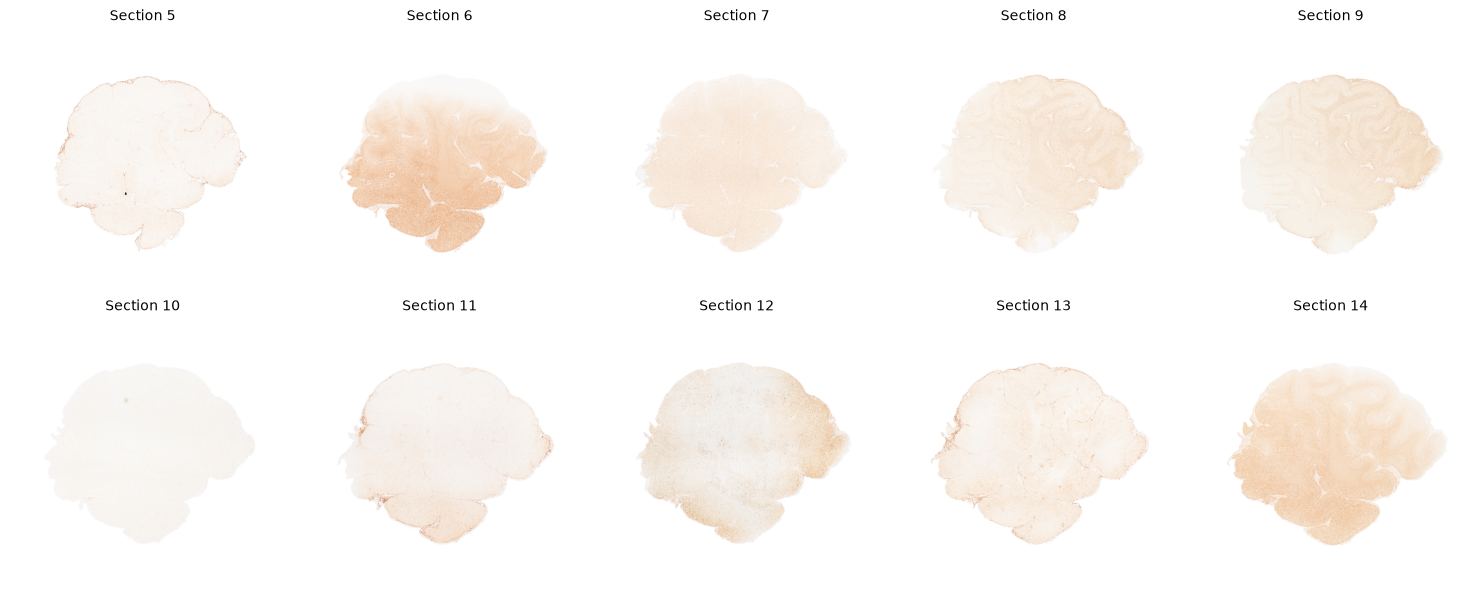

In [83]:
# Preview a range of sections (the end number is not included)
preview_sections(roi, start=5, end=15)

## 4. Prepare for ML

In [13]:
# Take a sub-stack of sections 5 to 14
sub = get_sections(roi, 5, 15)
print(sub.shape)

(6, 750, 750, 3)


In [14]:
# Colour (RGB) -> one grayscale channel
gray = to_grayscale(sub)
print(gray.shape)

(6, 750, 750)


In [15]:
# Crop the middle 256 x 256 pixels of every section
cropped = center_crop(gray, 100)
# Or pick exact rows/columns: crop_roi(gray, y=(50, 300), x=(50, 300))
print(cropped.shape)

(6, 100, 100)


In [16]:
# Make each section 2x smaller (averages neighbouring pixels)
small = downsample_roi(cropped, factor=2)
print(small.shape)

(6, 50, 50)


In [17]:
# Scale intensities to 0-1 (clip_percentiles ignores extreme outliers)
# Use method="zscore" for mean 0 / std 1 instead
x = normalize_roi(small, clip_percentiles=(1, 99))
print(x.dtype, x.min(), x.max())

float32 0.0 1.0


In [18]:
# Convert to a PyTorch tensor shaped (sections, channels, height, width)
tensor = to_torch(x)
print(tensor.shape)

torch.Size([6, 1, 50, 50])


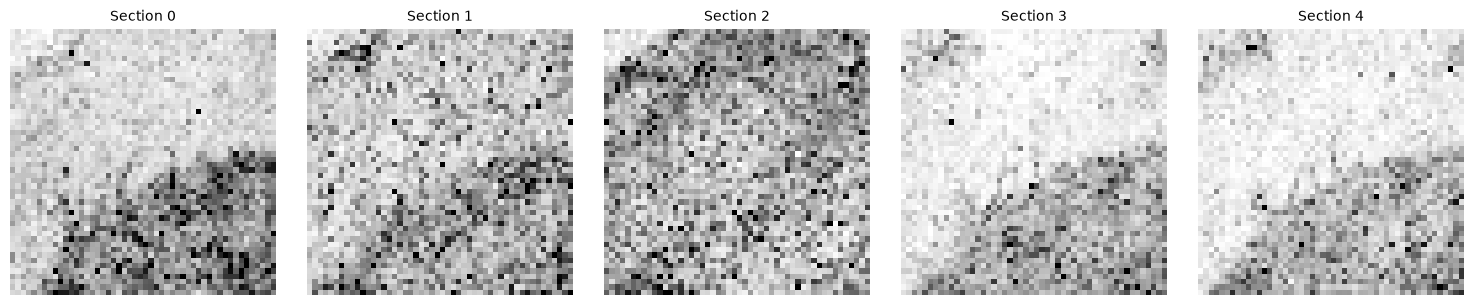

In [19]:
# Quick look at the final result
preview_sections(x, start=0, end=5)

In [63]:

# per-section QC table
import pandas as pd
st = section_stats(roi)                 # dict of per-section arrays
df = pd.DataFrame(st)
display(df.describe().T[["min","50%","max"]])


,min,50%,max
mean,197.039240,244.279301,251.405628
std,5.160064,10.918133,45.531760
p1,113.666664,215.333328,238.333328
p99,255.000000,255.000000,255.000000
dynamic_range,16.666672,39.666672,141.333336
sharpness,54.379906,411.267975,6377.544434
white_frac,0.308146,0.481394,0.906910
zero_frac,0.000000,0.000000,0.000024
tissue_frac,0.295948,0.602361,0.704766
section,0.000000,58.000000,116.000000


In [64]:
anomalies = find_section_anomalies(roi)
anomaly_df = pd.DataFrame(anomalies)
display(anomaly_df)


,section,d_prev,d_next,d_skip,score
0,115,0.427781,0.615706,0.166782,0.260999


In [84]:
rows = resolve_atlas_sections(
    anomaly_df["section"].tolist(),
    biosample_id=BIOSAMPLE_ID,
    stain=STAIN,
    center_section=meta["center_section"],
    n_sections=len(roi),
)

atlas_df = pd.DataFrame(rows)
display(atlas_df)


stack_index | biosample_id | stain | atlas_section
115         | 587          | IHCS  | 1661


,stack_index,biosample_id,stain,atlas_section,record
0,115,587,IHCS,1661,1661


,section,reason,value,expected_range
0,5,residual_background,0.861971,"(0.0, 0.05)"
1,10,residual_background,0.859153,"(0.0, 0.05)"
2,13,residual_background,0.692876,"(0.0, 0.05)"
3,20,sharpness_high,1510.374634,"(-383.6199844238281, 1192.5742080566406)"
4,20,residual_background,0.655930,"(0.0, 0.05)"
...,...,...,...,...
56,105,sharpness_high,4002.771240,"(-267.2425430175781, 1308.9516494628906)"
57,107,residual_background,0.570056,"(0.0, 0.05)"
58,110,residual_background,0.400416,"(0.0, 0.05)"
59,114,residual_background,0.418867,"(0.0, 0.05)"


0 expected end-of-series tapers


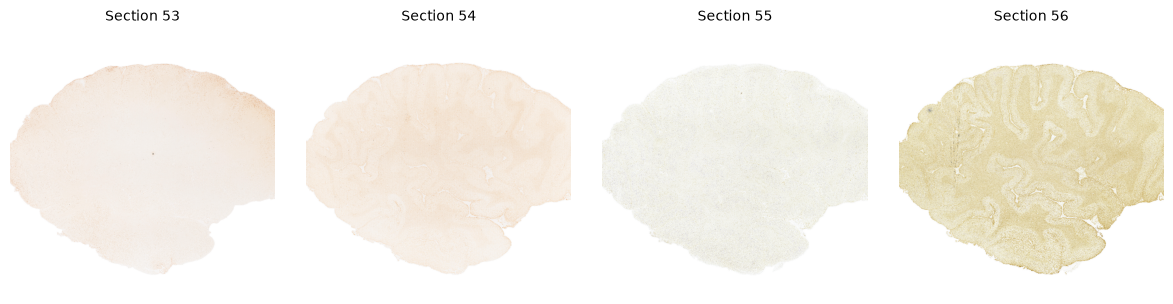

In [85]:
# flag bad sections (replaces find_outlier_sections)
flags = flag_sections(st)
flag_df = pd.DataFrame(flags, columns=["section","reason","value","expected_range"])
display(flag_df[~flag_df.reason.str.startswith("series_end")])   # real defects
print(len(flag_df[flag_df.reason.str.startswith("series_end")]), "expected end-of-series tapers")
preview_sections(roi, sections=[53, 54, 55, 56])


largest transitions (N -> N+1): [(115, 0.62), (114, 0.43), (83, 0.4), (103, 0.27), (66, 0.25)]


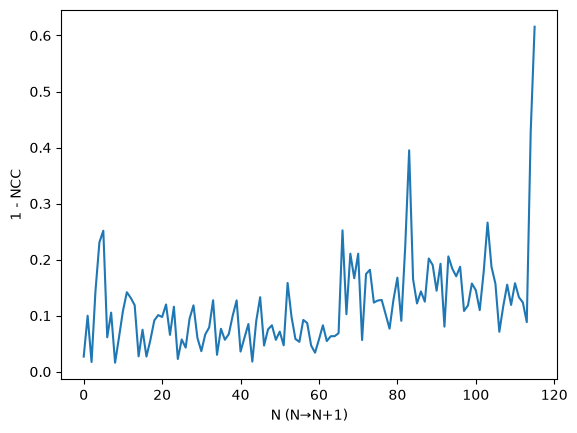

In [66]:

# Z-continuity
import numpy as np, matplotlib.pyplot as plt
d = adjacent_change(roi)                # 1 - NCC between sections N and N+1, length Z-1
z, ref, sc = local_zscore(d, window=9)
print("largest transitions (N -> N+1):", [(int(i), round(float(d[i]), 2)) for i in np.argsort(-d)[:5]])
plt.plot(d); plt.xlabel("N (N→N+1)"); plt.ylabel("1 - NCC"); plt.show()


========== Section 5 ==========


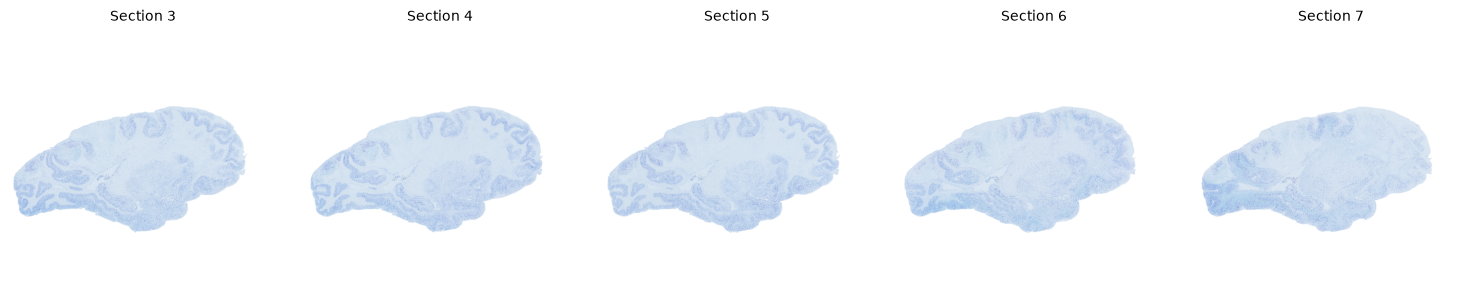


========== Section 8 ==========


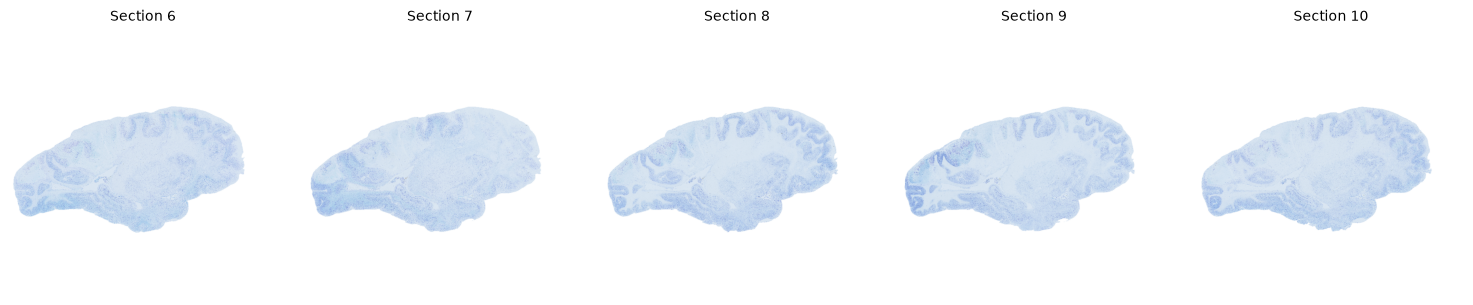


========== Section 15 ==========


IndexError: No valid sections; this stack has sections 0..10.

In [24]:
for s in [5, 8, 15, 54, 80, 102, 108]:
    print(f"\n========== Section {s} ==========")
    preview_sections(
        roi,
        sections=[s-2, s-1, s, s+1, s+2]
    )

In [ ]:

# tissue mask and OD for a single section
m = tissue_mask(roi[len(roi)//2])       # bool (H, W)
od = to_od(roi[len(roi)//2])            # summed optical density, white ≈ 0
print("coverage:", m.mean())

## 5. Stroke Histology Annotations

Overlay pathology annotations (GFAP, CD68, FIB, ...) from the c-stroke OpenAtlas API on this ROI, measure their morphology, and compare them across proteins and sections. Helpers live in `annotations_utils.py`, next to `roi_utils.py`. **The ROI array is only read, never modified.**

Workflow: **load → inspect → visualize → measure → compare → understand.**

In [119]:
# !wget -q -O annotations_utils.py https://raw.githubusercontent.com/24f2007780/colab_export_roi/refs/heads/main/annotations_utils.py

import sys
from pathlib import Path
if ".." not in sys.path:
    sys.path.append("..")

import importlib
import annotations_utils
importlib.reload(annotations_utils)
from annotations_utils import *
import pandas as pd


#### 5.1 Which annotation types exist for this section?

The section is the one the ROI stack is centred on (`meta["center_section"]`). Only HTTP headers are checked here — no geometry is downloaded yet — so this is a cheap way to see which stains were actually annotated before loading anything.

In [120]:
SECTION = meta["center_section"]      # Atlas section the stack is centred on
available = find_available_annotations(
    biosample_id=BIOSAMPLE_ID,
    stain=STAIN,
    section_num=SECTION,
)
display(pd.DataFrame(available))


,protein,description,available,url,status,error
0,CD68,Microglial density (CD68+),False,https://c-stroke.humanbrain.in/histology_detec...,200,None
1,GFAP,Astrocyte density (GFAP+),False,https://c-stroke.humanbrain.in/histology_detec...,200,None
2,FIB,BBB disruption (Fib+),True,https://c-stroke.humanbrain.in/histology_detec...,200,None
3,CD34,Vessel density (CD34+),False,https://c-stroke.humanbrain.in/histology_detec...,200,None
4,HIF1a,Hypoxic regions (HIF1a+),False,https://c-stroke.humanbrain.in/histology_detec...,200,None
5,Nissl,Cell density (Nissl+),False,https://c-stroke.humanbrain.in/histology_detec...,200,None
6,H&E,Infarct (H&E),False,https://c-stroke.humanbrain.in/histology_detec...,200,None
7,APP,Axonal injury (APP+),False,https://c-stroke.humanbrain.in/histology_detec...,200,None
8,GAP43,Axonal regrowth (GAP43+),False,https://c-stroke.humanbrain.in/histology_detec...,200,None


#### 5.2 Load the annotations (registered coordinates)

Only the proteins flagged `available=True` above are downloaded. Coordinates are still in the Stroke/OpenAtlas registered space here, not yet ROI pixels.

In [121]:
annotations = load_stroke_annotations(
    biosample_id=BIOSAMPLE_ID,
    stain=STAIN,
    section_num=SECTION,
)
print(len(annotations), "polygons;", sorted({a["protein"] for a in annotations}))
print(annotation_bounds(annotations))   # extent in registered units / implied full-resolution pixels


17 polygons; ['FIB']
{'registered_x': (57015.886163361865, 112106.20578194753), 'registered_y': (-125007.35148899874, -66655.10337096373), 'fullres_px_x': (7126.985770420233, 14013.275722743441), 'fullres_px_y': (8331.887921370466, 15625.918936124843)}


#### 5.3 Overlay on the ROI section

Overlay them on the corresponding ROI section. The ROI metadata (`center_X`, `center_Y`, level) decides where the ROI sits in the registered space; polygons are clipped to the ROI. `find_stack_index` returns the stack index whose Atlas section is `SECTION`, so the annotations are drawn on the tissue they were made for (it raises an error if the stack does not contain that section).

In [ ]:
section_index = find_stack_index(roi, meta, SECTION, biosample_id=BIOSAMPLE_ID)
annotations_in_roi = to_roi_coordinates(annotations, roi, meta)   # new records; `annotations` is untouched
print(f"stack section {section_index} = Atlas section {SECTION}:",
      len(annotations_in_roi), "of", len(annotations), "polygons intersect the ROI")
preview_annotations(roi, annotations_in_roi, section_index=section_index)


#### 5.4 Whole ROI stack

Stack index → Atlas section (via `resolve_atlas_sections`) → available proteins → polygons → ROI coordinates → clipped. Sections can have different annotation types.

In [123]:
roi_annotations = load_roi_annotations(
    roi,
    meta,
    biosample_id=BIOSAMPLE_ID,
    stain=STAIN,
)
# roi_annotations[stack_index]            -> {protein: [records]}
# roi_annotations[stack_index]["FIB"]     -> polygons (a KeyError means that protein does not exist for that section)
sections_with_annotations = [i for i, d in roi_annotations.items() if any(d.values())]
print(f"{len(sections_with_annotations)} of {len(roi_annotations)} stack sections have at least one polygon in the ROI")


ROI 768x768px, origin (level px) = (366, 366), level_factor=16, 8 registered units per full-res px -> 128 units per ROI px, offset=(0, 0) units, y_sign=-1
117 stack sections, 98 with annotation files, 85 with polygons inside the ROI
  CD34   Vessel density (CD34+)      in 22 sections, 676 polygons in the ROI
  GAP43  Axonal regrowth (GAP43+)    in 8 sections, 0 polygons in the ROI
  GFAP   Astrocyte density (GFAP+)   in 18 sections, 3766 polygons in the ROI
  HIF1a  Hypoxic regions (HIF1a+)    in 11 sections, 542 polygons in the ROI
  FIB    BBB disruption (Fib+)       in 21 sections, 294 polygons in the ROI
  CD68   Microglial density (CD68+)  in 18 sections, 543 polygons in the ROI
85 of 117 stack sections have at least one polygon in the ROI


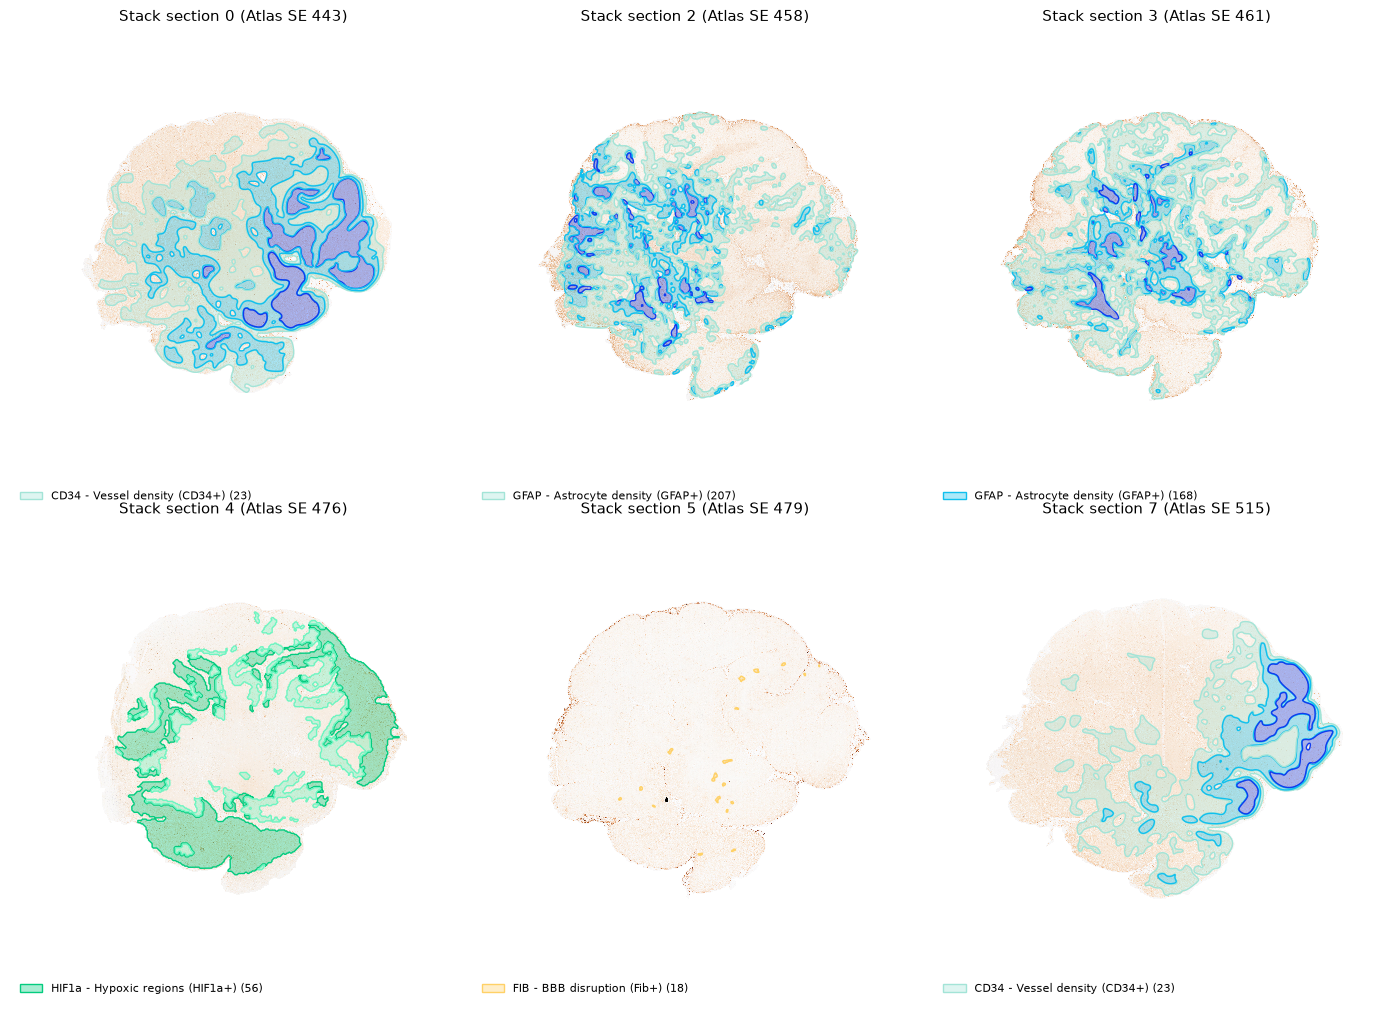

In [124]:
# Gallery of other annotated sections across the stack (section_index was already inspected above)
import matplotlib.pyplot as plt

other_sections = [i for i in sections_with_annotations if i != section_index]
if other_sections:
    preview_idx = other_sections[:6]
    ncols = min(len(preview_idx), 3)
    nrows = (len(preview_idx) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), squeeze=False)
    for i, ax in zip(preview_idx, axes.ravel()):
        preview_annotations(roi, roi_annotations, section_index=i, ax=ax, show=False)
    for ax in axes.ravel()[len(preview_idx):]:
        ax.axis("off")
    fig.tight_layout()
    plt.show()
elif sections_with_annotations:
    print(f"Stack section {section_index} is the only section with annotations in this ROI (previewed above in §5.3).")
else:
    print("No sections in this ROI stack have annotations inside the ROI.")


In [125]:
# The original ROI is never written to; check it yourself:
import hashlib
before = hashlib.sha256(roi.tobytes()).hexdigest()
_ = create_annotation_overlay(roi, roi_annotations, section_index=section_index)
assert hashlib.sha256(roi.tobytes()).hexdigest() == before
print("roi unchanged")


roi unchanged


#### 5.5 Quantitative Annotation Analysis & Morphology

Now that the annotations are clipped to the ROI (`annotations_in_roi`, from §5.3), measure their shape. `compute_annotation_properties` reports, per polygon:
- **area** and **perimeter**
- **circularity** ($4\pi \cdot \text{area} / \text{perimeter}^2$; 1.0 = a smooth circle, lower = irregular/branching)
- **aspect ratio** and **major / minor axis** (from the minimum rotated bounding box)
- **orientation** (angle of the long axis, degrees)
- **max width** (thickness, via the largest inscribed circle)
- **tissue coverage** (fraction of the section's real tissue area the polygon covers)

In [93]:
# Compute morphological properties for the annotations in our ROI
props = compute_annotation_properties(annotations_in_roi, roi=roi, section_index=section_index)
df_props = pd.DataFrame(props)

cols = ["protein", "feature_id", "class_name", "area", "perimeter", "circularity", "aspect_ratio", "max_width", "tissue_coverage"]
if not df_props.empty:
    display(df_props[[c for c in cols if c in df_props.columns]])
else:
    print(f"No annotations in ROI for section {section_index} to compute properties.")


,protein,feature_id,class_name,area,perimeter,circularity,aspect_ratio,max_width,tissue_coverage
0,FIB,4399,blood brain barrier disruption,19.170314,16.619429,0.872182,1.742083,3.596804,0.000054
1,FIB,2310,blood brain barrier disruption,24.111246,18.083740,0.926516,1.419664,4.588646,0.000068
2,FIB,2524,blood brain barrier disruption,14.820010,14.312582,0.909122,1.451820,3.536213,0.000042
3,FIB,3999,blood brain barrier disruption,12.282680,15.409997,0.649977,2.314230,2.645518,0.000035
4,FIB,1044,blood brain barrier disruption,55.685692,35.218129,0.564184,1.336333,4.577475,0.000157
5,FIB,585,blood brain barrier disruption,46.047341,25.856115,0.865541,1.281054,6.264787,0.000130
6,FIB,1304,blood brain barrier disruption,23.494152,18.800598,0.835269,1.416481,4.368684,0.000066
7,FIB,1792,blood brain barrier disruption,41.567488,30.813319,0.550157,2.589420,4.668557,0.000117
8,FIB,2032,blood brain barrier disruption,13.167925,14.783558,0.757128,1.864315,3.064776,0.000037
9,FIB,5016,blood brain barrier disruption,13.654775,14.596864,0.805333,1.939715,3.042967,0.000038


*Note on units*: By default, measurements are in ROI pixels (`units="roi_px"`), which are **not** a physical unit — they already bake in both the scanner's resolution and whatever ROI pyramid level you extracted (`T.units_per_px`, printed in §5.4 for this ROI). To get real-world sizes, pass `units="um"` or `"mm"` together with `mpp` = microns-per-ROI-pixel **at this specific ROI level**, taken from your own scanner/pyramid calibration — never assumed. `centroid` and `bbox` come back in that same `units`, consistent with everything else.

**Exercise**: Check the circularity and aspect ratio of your lesions above. Compact lesions have circularity close to 1.0, while elongated or branching lesions have lower circularity and higher aspect ratios.

In [130]:
# `mpp` must come from YOUR scanner/pyramid calibration (microns per pixel AT THIS ROI LEVEL):
#   mpp_this_level = mpp_level0 * T.level_factor      (T = make_roi_transform(roi, meta))
# No such calibration is recorded anywhere in this pipeline, so a number is never guessed here —
# fill in MPP_THIS_LEVEL yourself before trusting any physical-unit result.
MPP_THIS_LEVEL = None   # e.g. 0.5 * make_roi_transform(roi, meta).level_factor

if MPP_THIS_LEVEL and annotations_in_roi:
    props_um = compute_annotation_properties(annotations_in_roi, units="um", mpp=MPP_THIS_LEVEL)
    df_um = pd.DataFrame(props_um)
    total_area_mm2 = df_um["area"].sum() / 1e6 if "area" in df_um.columns else 0.0
    print(f"Total lesion area: {total_area_mm2:.2f} mm² across {len(df_um)} detections")
elif not annotations_in_roi:
    print("No annotations in ROI to convert to physical units.")
else:
    print("Set MPP_THIS_LEVEL to your scanner calibration to see physical-unit areas.")


Total lesion area: 0.03 mm² across 17 detections


#### Comparing proteins across the whole ROI stack

Single-section morphology is useful for one slice; across the whole stack, `roi_annotations.records()` returns every polygon from every section and every protein, which `compute_annotation_properties` turns into one measurement table. Grouping it by protein compares their typical size, shape and overall burden in this ROI — e.g. "which pathology is most extensive here?"

In [131]:
all_props = compute_annotation_properties(roi_annotations.records())
df_all = pd.DataFrame(all_props)

if not df_all.empty and "protein" in df_all.columns:
    protein_summary = df_all.groupby("protein").agg(
        n_polygons=("area", "size"),
        n_sections=("section", "nunique"),
        mean_area=("area", "mean"),
        median_circularity=("circularity", "median"),
        mean_aspect_ratio=("aspect_ratio", "mean"),
        total_area=("area", "sum"),
    ).round(2).sort_values("total_area", ascending=False)
    display(protein_summary)
else:
    print("No annotations found across the ROI stack to summarize.")


,n_polygons,n_sections,mean_area,median_circularity,mean_aspect_ratio,total_area
protein,,,,,,
CD34,676,22,4122.81,0.44,1.86,2787021.54
GFAP,3766,18,519.23,0.64,2.04,1955425.95
CD68,543,18,3140.75,0.56,2.23,1705428.38
HIF1a,542,11,1414.28,0.36,2.21,766540.28
FIB,294,16,310.15,0.76,1.96,91184.36


#### 5.6 Filtering Annotations by Class, Acronym, and Size

Histology detections often include multiple subtypes (e.g. light, moderate, or dense staining) stored in `properties["data"]`. Use `filter_annotations` to isolate specific subtypes or filter out small noise fragments.

In [ ]:
# Keep only the larger lesions (small fragments are often noise/debris).
if not df_props.empty and "area" in df_props.columns and len(annotations_in_roi) > 0:
    AREA_THRESHOLD = float(df_props["area"].median())
    large_lesions = filter_annotations(annotations_in_roi, min_area=AREA_THRESHOLD)
    print(f"Retained {len(large_lesions)} of {len(annotations_in_roi)} annotations with area >= {AREA_THRESHOLD:.1f} ROI px²")
    preview_annotations(roi, large_lesions, section_index=section_index)
else:
    large_lesions = []
    print("No annotations on this section to filter.")


#### 5.7 Quality Control: Validating Annotations Against Real Tissue

Automated detectors sometimes produce false positives on empty slide glass or near specimen tears. `validate_roi_annotations` tests how much of each annotation polygon actually overlaps with real histological tissue using `tissue_mask`.

In [133]:
# Check whether annotations sit on real tissue (flagging any with < 50% tissue overlap)
qc = validate_roi_annotations(roi, annotations_in_roi, section_index=section_index, min_tissue_fraction=0.5)

print("Validation summary:", qc["summary"])
qc_df = pd.DataFrame(qc["details"])
cols = ["protein", "feature_id", "tissue_fraction", "valid"]
if not qc_df.empty:
    display(qc_df[[c for c in cols if c in qc_df.columns]])


Validation summary: {'total': 17, 'valid_count': 17, 'flagged_count': 0, 'valid_rate': 1.0, 'min_tissue_fraction': 0.5}


,protein,feature_id,tissue_fraction,valid
0,FIB,4399,1.0,True
1,FIB,2310,1.0,True
2,FIB,2524,1.0,True
3,FIB,3999,1.0,True
4,FIB,1044,1.0,True
5,FIB,585,1.0,True
6,FIB,1304,1.0,True
7,FIB,1792,1.0,True
8,FIB,2032,1.0,True
9,FIB,5016,1.0,True


**Exercise**: If any detections are flagged (`qc["flagged"]`), preview them on the section image to see if they correspond to tissue tears, edge artifacts, or glass debris.

#### 5.8 Spatial Overlap & Co-Localization

Two different protein stains can be compared on the same section with `compute_annotation_overlap` (Sørensen–Dice, IoU, or raw intersection area) — e.g. do astrocyte reactivity (GFAP) and microglial activation (CD68) occupy the same tissue, or different territory? This needs a section where both proteins were actually annotated, found automatically below from the whole-stack load in §5.4.

In [134]:
# Find a stack section where at least two different proteins have polygons inside the ROI
candidates = [(i, [p for p, rs in roi_annotations[i].items() if rs]) for i in sections_with_annotations]
multi = [(i, ps) for i, ps in candidates if len(ps) >= 2]

if multi:
    co_section, co_proteins = multi[0]
    p1, p2 = co_proteins[:2]
    set_a, set_b = roi_annotations[co_section][p1], roi_annotations[co_section][p2]
    dice = compute_annotation_overlap(set_a, set_b, mode="dice")
    iou = compute_annotation_overlap(set_a, set_b, mode="iou")
    print(f"Stack section {co_section}: {p1} ({len(set_a)} polygons) vs {p2} ({len(set_b)} polygons) "
          f"-> Dice = {dice:.3f}, IoU = {iou:.3f}")
    preview_annotations(roi, roi_annotations, section_index=co_section, proteins=[p1, p2])
else:
    print("No stack section in this ROI has 2+ proteins annotated; co-localization needs a multi-stain section.")

No stack section in this ROI has 2+ proteins annotated; co-localization needs a multi-stain section.


#### 5.9 Coordinate Inversion: ROI Pixels → Global Registered Space

Found an interesting lesion in the ROI and want to locate it on the original full-resolution slide (or cross-reference it with MRI)? `RoiTransform.invert` maps a ROI pixel back to the Stroke/OpenAtlas registered (level-0) coordinates — the same space the original annotation JSON used. Demonstrated below on the centroid of the largest lesion retained in §5.6, not an arbitrary point.

In [135]:
# Locate the largest lesion centroid back in the original registered (level-0) space
T = make_roi_transform(roi, meta)
target_records = large_lesions if large_lesions else annotations_in_roi
lesion_props = compute_annotation_properties(target_records) if target_records else []

if lesion_props:
    biggest = max(lesion_props, key=lambda p: p["area"])
    roi_xy = biggest["centroid"]
    registered_xy = T.invert(roi_xy)
    print(f"Largest lesion ({biggest['protein']} #{biggest['feature_id']}, area={biggest['area']:.1f} ROI px²):")
    print(f"  ROI pixel {tuple(round(v, 1) for v in roi_xy)} -> registered (X, Y) = {tuple(registered_xy.round(1))}")
    print(f"  round-trip check: {T.apply(registered_xy).round(2)}")
else:
    roi_center = [roi.shape[2] // 2, roi.shape[1] // 2]
    registered_xy = T.invert(roi_center)
    print(f"No lesions in ROI to invert; demonstrating on ROI center pixel {roi_center}:")
    print(f"  ROI pixel {roi_center} -> registered (X, Y) = {tuple(registered_xy.round(1))}")
    print(f"  round-trip check: {T.apply(registered_xy).round(2)}")


Largest retained lesion (FIB #1044, area=55.7 ROI px²):
  ROI pixel (384.8, 536.9) -> registered (X, Y) = (np.float64(96107.3), np.float64(-115571.3))
  round-trip check: [384.84 536.9 ]


#### 5.10 3D Stack Volumetric Masks

For volumetric quantification or 3D multi-modal alignment (e.g. comparing histology against 3D MRI DWI/ADC grids), convert the stack's annotations into full `(Z, H, W)` boolean volumes.

In [136]:
# Build 3D boolean volumes matching the entire ROI stack dimensions
stack_masks = create_stack_annotation_masks(roi, roi_annotations)

if stack_masks:
    for protein, mask_3d in stack_masks.items():
        annotated_sections = np.where(mask_3d.any(axis=(1, 2)))[0]
        total_voxels = np.count_nonzero(mask_3d)
        print(f"{protein:<6}: volume shape {mask_3d.shape}, active stack sections: {annotated_sections.tolist()}, total positive pixels: {total_voxels}")
else:
    print("No annotation masks created (no annotations found inside this ROI stack).")


CD34  : volume shape (117, 768, 768), active stack sections: [0, 7, 20, 34, 38, 42, 50, 57, 66, 67, 70, 73, 75, 77, 80, 87, 88, 93, 97, 102, 106, 111], total positive pixels: 2530174
GFAP  : volume shape (117, 768, 768), active stack sections: [2, 3, 8, 9, 24, 25, 26, 40, 43, 54, 56, 60, 76, 85, 91, 110, 113, 116], total positive pixels: 1897653
HIF1a : volume shape (117, 768, 768), active stack sections: [4, 12, 18, 53, 89, 94, 95, 99, 103, 108, 112], total positive pixels: 803365
FIB   : volume shape (117, 768, 768), active stack sections: [5, 11, 13, 19, 22, 23, 41, 45, 51, 58, 69, 71, 74, 82, 100, 115], total positive pixels: 95584
CD68  : volume shape (117, 768, 768), active stack sections: [10, 27, 30, 31, 37, 44, 47, 52, 55, 59, 62, 79, 86, 92, 98, 101, 107, 114], total positive pixels: 1711949
